## Wine types classification

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)

import seaborn as sns
import matplotlib.pyplot as plt


plt.style.use("bmh")
np.random.seed(42)

In [2]:
red_wine_data = pd.read_csv('data/winequality-red.csv', delimiter=';')
white_wine_data = pd.read_csv('data/winequality-white.csv', delimiter=';')

## EDA

In [3]:
red_wine_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Classes description

- Minor classes disbalance (1600 red vs 4900 white)
- Similar statistics per classes 

In [4]:
white_wine_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [5]:
red_wine_data['class'] = 'red'
white_wine_data['class'] = 'white'
wine_data = pd.concat([red_wine_data, white_wine_data], axis=0, ignore_index=True)
wine_data.isnull().sum()

wine_data['target'] = np.where(wine_data['class']=='white', 1, 0)
wine_data.drop(columns=['class'], inplace=True)

volatile acidity       -0.653036
chlorides              -0.512678
sulphates              -0.487218
fixed acidity          -0.486740
density                -0.390645
pH                     -0.329129
alcohol                 0.032970
quality                 0.119323
citric acid             0.187397
residual sugar          0.348821
free sulfur dioxide     0.471644
total sulfur dioxide    0.700357
target                  1.000000
Name: target, dtype: float64

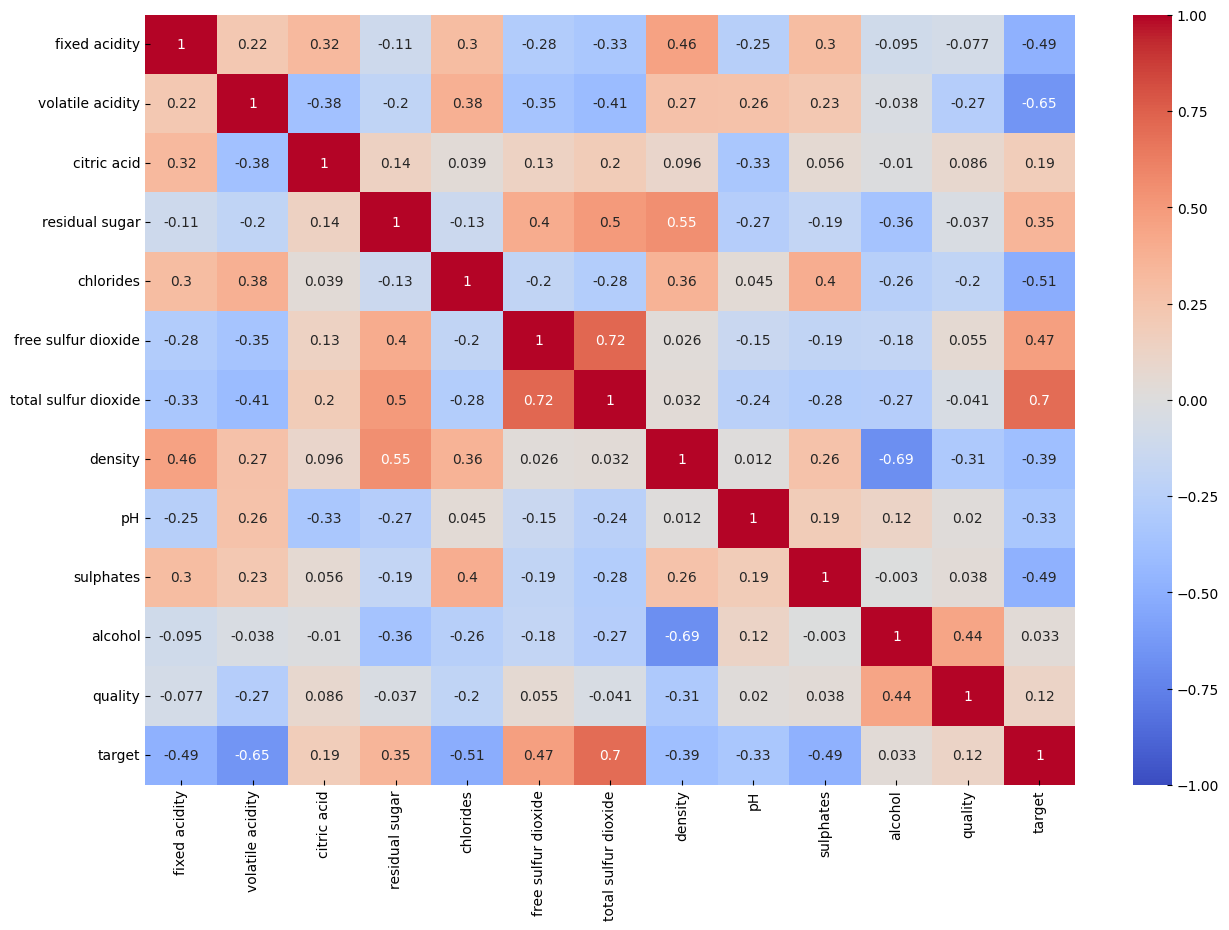

In [6]:
display(wine_data.corr()['target'].sort_values(ascending=True))

plt.figure(figsize=(15,10))
sns.heatmap(wine_data.corr(), annot=True, vmin=-1, vmax=1, cmap='coolwarm')
plt.grid(None)
plt.show()

### Correlations

#### With Non target

- Free Sulfur Dioxide and Total Sulfur Dioxide are positively correlated.
- Density and Alcohol have a negative correlation relationship.
- Density has a positive correlation with the Fixed Acidity and Residual Sugar.
- Quality is also positively linked with the amount of Alcohol.
- Volatile Acidity has a negative correlation with the Total Sulfur Dioxide.

#### With Target

- Volatile Acidity
- Fixed Acidity
- Chlorides
- Total Sulfur Dioxide
- Sulphates
- Free Sulfur Dioxide

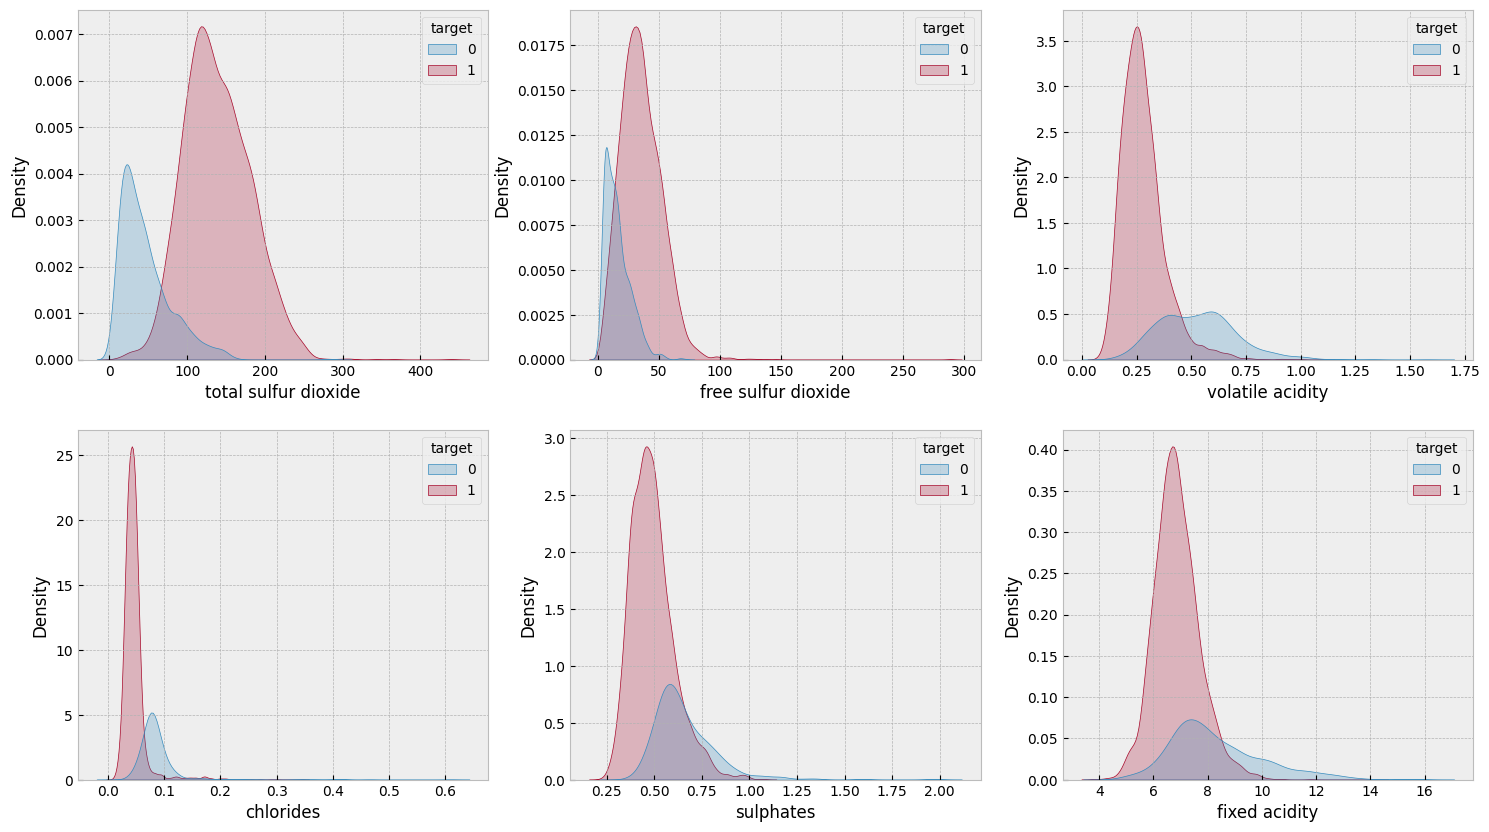

In [7]:
fig, axes = plt.subplots(2,3, figsize=(18, 10))
sns.kdeplot(data=wine_data, x='total sulfur dioxide', hue='target', fill='class', ax=axes[0, 0])
sns.kdeplot(data=wine_data, x='free sulfur dioxide', hue='target', fill='class', ax=axes[0, 1])
sns.kdeplot(data=wine_data, x='volatile acidity', hue='target', fill='class', ax=axes[0, 2])
sns.kdeplot(data=wine_data, x='chlorides', hue='target', fill='class', ax=axes[1, 0])
sns.kdeplot(data=wine_data, x='sulphates', hue='target', fill='class', ax=axes[1, 1])
sns.kdeplot(data=wine_data, x='fixed acidity', hue='target', fill='class', ax=axes[1, 2])
plt.show()

### Training

- Linear SVM
- RBF SVM
- Poly SVM
- Hist Gradient Boosting

,model,accuracy,precision,recall,f1,roc_auc
1,svc_rbf,0.995692,0.995192,0.999195,0.997190,0.997129
3,gb_hist,0.993231,0.992800,0.998391,0.995588,0.996022
0,svc_linear,0.992000,0.995968,0.993564,0.994764,0.991134
2,svc_poly,0.991385,0.993574,0.995173,0.994373,0.993556


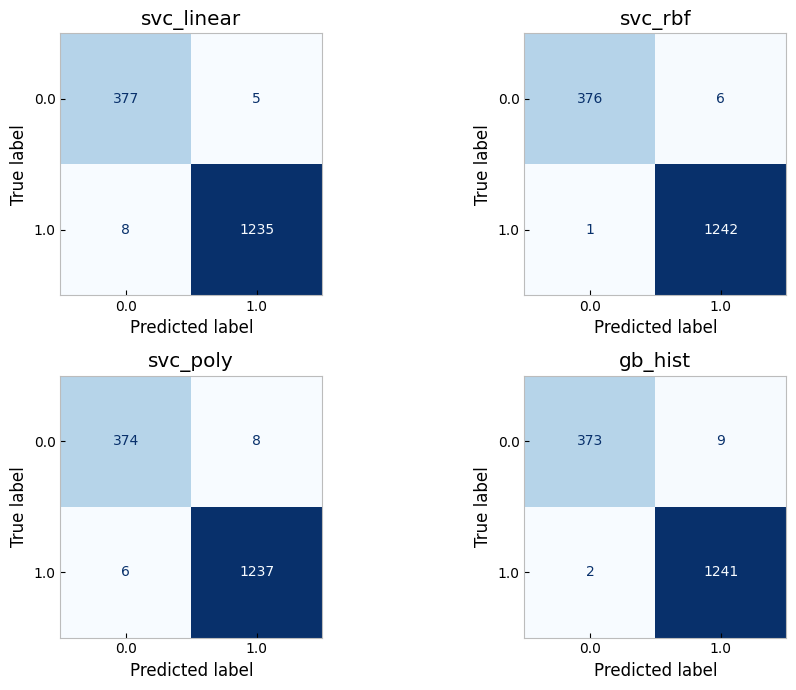

In [13]:
wine_data = wine_data.astype('float32')
data_X = wine_data.drop('target', axis=1)
data_y = wine_data['target']

X_train, X_test, y_train, y_test = train_test_split(data_X, data_y, test_size=0.25, random_state=1)


def evaluate_model(name, estimator, X_tr, y_tr, X_te, y_te):
    estimator.fit(X_tr, y_tr)
    y_pred_local = estimator.predict(X_te)
    if hasattr(estimator, 'decision_function'):
        y_score_local = estimator.decision_function(X_te)
    elif hasattr(estimator, 'predict_proba'):
        y_score_local = estimator.predict_proba(X_te)[:, 1]
    else:
        y_score_local = y_pred_local

    return {
        'model': name,
        'accuracy': accuracy_score(y_te, y_pred_local),
        'precision': precision_score(y_te, y_pred_local),
        'recall': recall_score(y_te, y_pred_local),
        'f1': f1_score(y_te, y_pred_local),
        'roc_auc': roc_auc_score(y_te, y_score_local),
        'y_pred': y_pred_local,
        'y_score': y_score_local,
        'y_true': y_te,
    }


linear_result = evaluate_model(
    'svc_linear',
    Pipeline([
        ('scaler', StandardScaler()),
        ('svc', LinearSVC(C=1.0, class_weight='balanced', dual='auto', random_state=42))
    ]),
    X_train, y_train, X_test, y_test
)
rbf_result = evaluate_model(
    'svc_rbf',
    Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', C=5.0, gamma='scale', class_weight='balanced'))
    ]),
    X_train, y_train, X_test, y_test
)
poly_result = evaluate_model(
    'svc_poly',
    Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='poly', degree=3, C=3.0, gamma='scale', coef0=1.0, class_weight='balanced'))
    ]),
    X_train, y_train, X_test, y_test
)
gb_hist_result = evaluate_model(
    'gb_hist',
    Pipeline([
        ('scaler', StandardScaler()),
        ('gb', HistGradientBoostingClassifier(max_iter=300, learning_rate=0.07, random_state=42))
    ]),
    X_train, y_train, X_test, y_test
)

results_df = pd.DataFrame([
    {k: linear_result[k] for k in ['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']},
    {k: rbf_result[k] for k in ['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']},
    {k: poly_result[k] for k in ['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']},
    {k: gb_hist_result[k] for k in ['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']},
]).sort_values('f1', ascending=False)
display(results_df)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, result in zip(axes.ravel(), [linear_result, rbf_result, poly_result, gb_hist_result]):
    ConfusionMatrixDisplay.from_predictions(
        result['y_true'],
        result['y_pred'],
        ax=ax,
        cmap="Blues",
        colorbar=False,
    )
    ax.grid(None)
    ax.set_title(result['model'])

plt.tight_layout()
plt.show()

model_results = {
    'svm_linear': linear_result,
    'svm_rbf': rbf_result,
    'svm_poly': poly_result,
    'gb_hist': gb_hist_result,
}

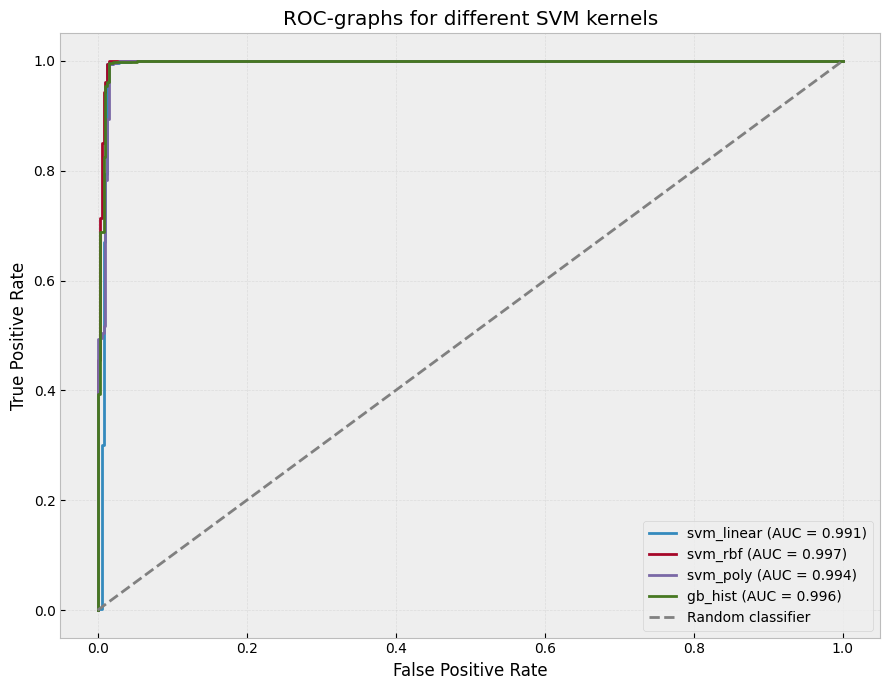

In [14]:
plt.figure(figsize=(9, 7))
for name, result in model_results.items():
    fpr_local, tpr_local, _ = roc_curve(result['y_true'], result['y_score'])
    plt.plot(fpr_local, tpr_local, linewidth=2, label=f"{name} (AUC = {result['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], '--', color='gray', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-graphs for different SVM kernels')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()